<a href="https://colab.research.google.com/github/andyotani/andyotani-PCVK_Ganjil_26-27/blob/main/Jobsheet02/JS02_pcvk_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  PRAKTIKUM

Pengenalan Python: Pengolahan Citra Dasar dan memahami channel warna pada OpenCV dan konversinya

In [ ]:
#1. Membuat koneksi antara Colab dengan Google Drive agar bisa mengakses file di dalamnya.
# Menggunakan file yang sama dengan praktikum pada D2, import folder yang ada di Drive Anda dengan cara sebagai berikut.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Cara yang kedua dengan:
# a. mengklik tombol folder di sebelah kiri
# Pilih tombol gdrive 🡪 Connect to Google Drive. Drive akan muncul dalam list folder:
# Pilih folder dan klik icon titik 3 disebelah kanan file gambar yang akan digunakan. klik copy path, dan bisa digunakan pada code berikutnya:


In [5]:
# Penjelasan diatas adalah cara mengakses gambar yang tersimpan di Google Drive (Cloud), namun jika posisi gambar tersimpan di computer
# local/laptop maka cara aksesnya bisa menggunakan fungsi upload gambar. Adapun caranya adalah sebagai berikut:
# Mengakses gambar dengan fungsi upload file
from google.colab import files
uploaded = files.upload()
# Jika Choose Files di klik, akan muncul direktori dari computer local.

Saving ktm.jpg to ktm.jpg


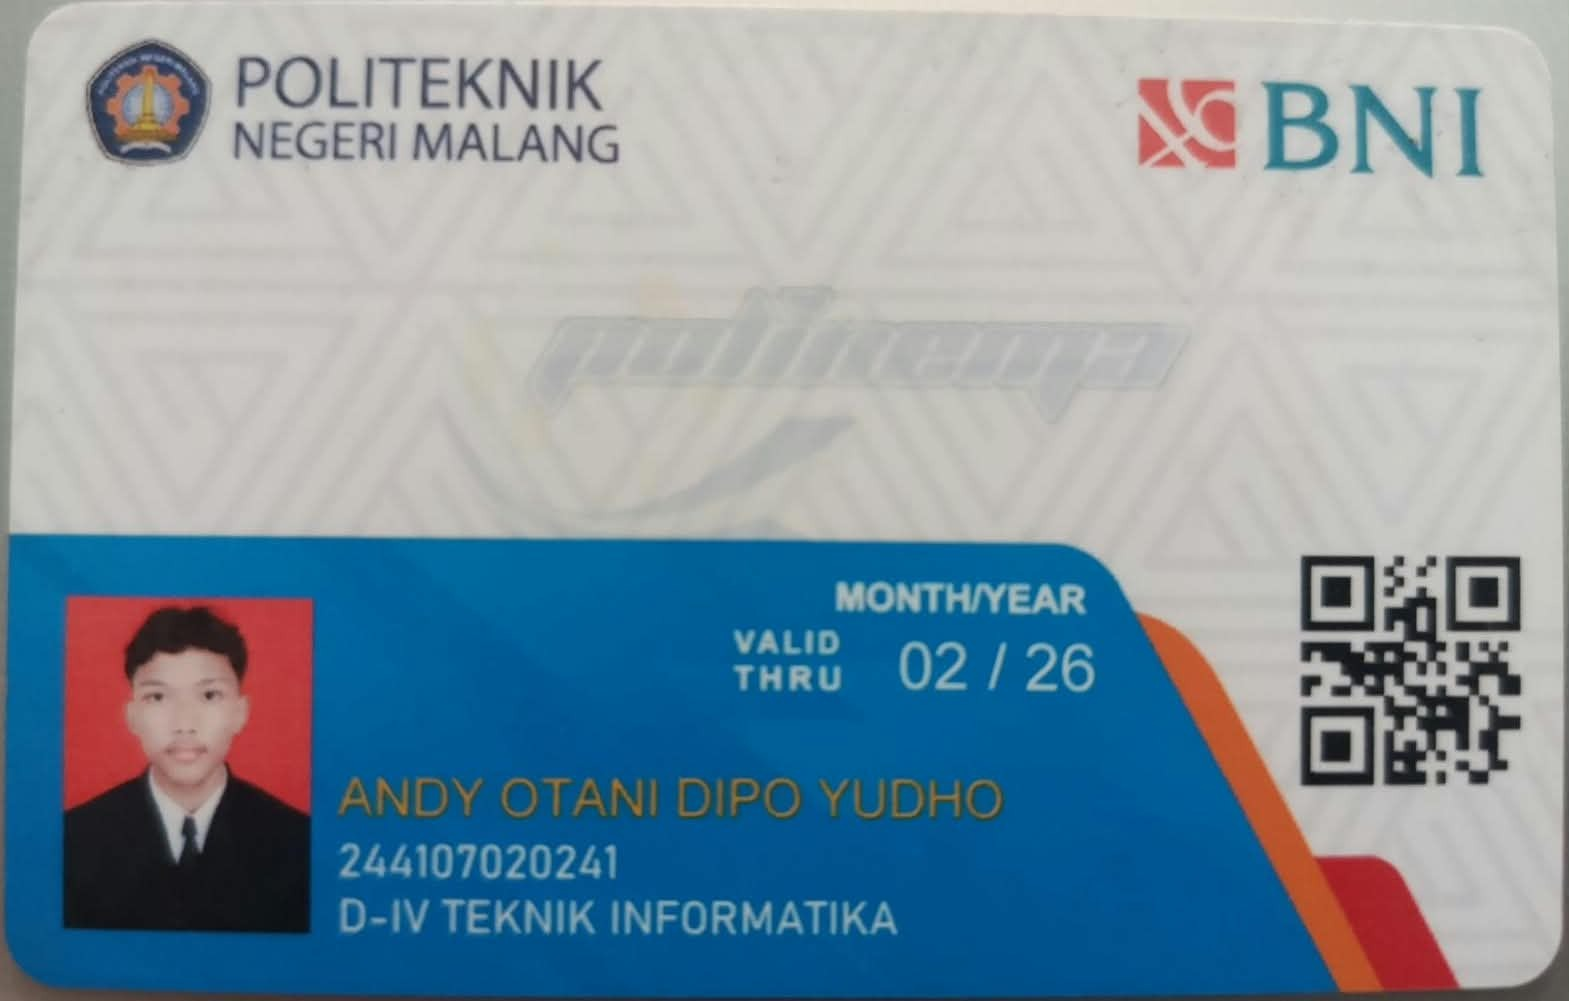

Resolusi gambar:  1569  x  1001


In [7]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np

img = cv.imread('ktm.jpg')
cv2_imshow(img)

print("Resolusi gambar: ", img.shape[1], " x ", img.shape[0])

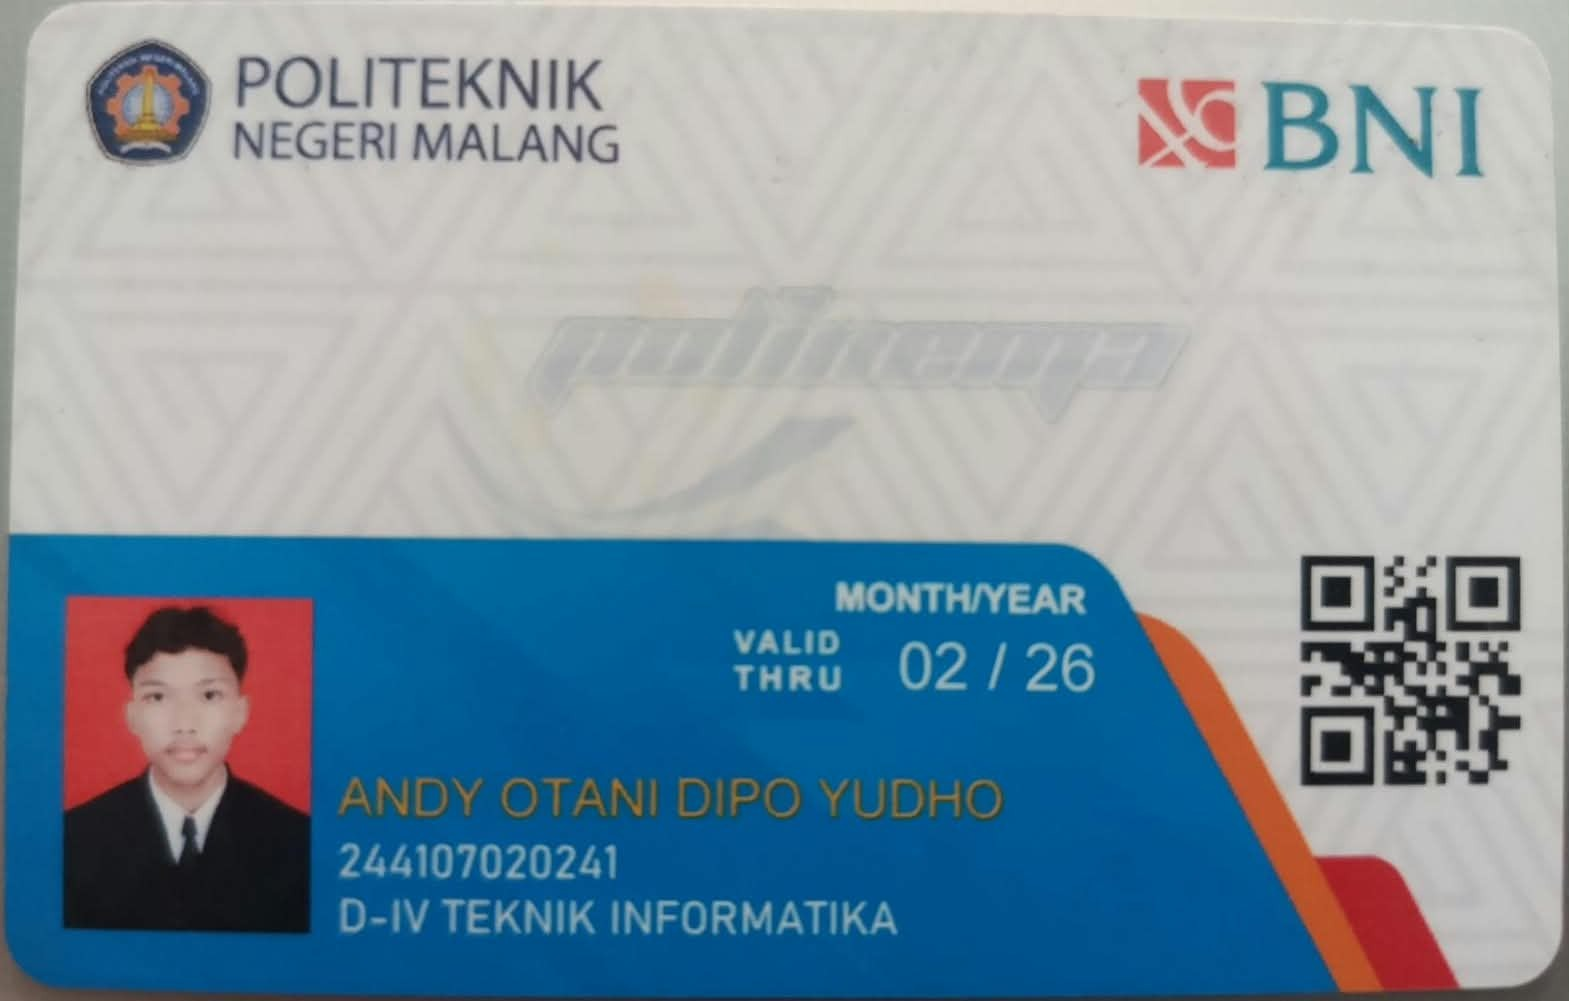

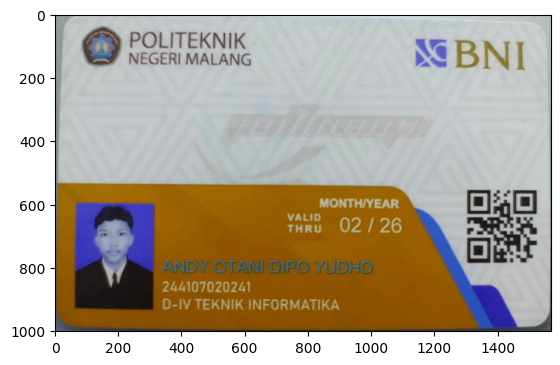

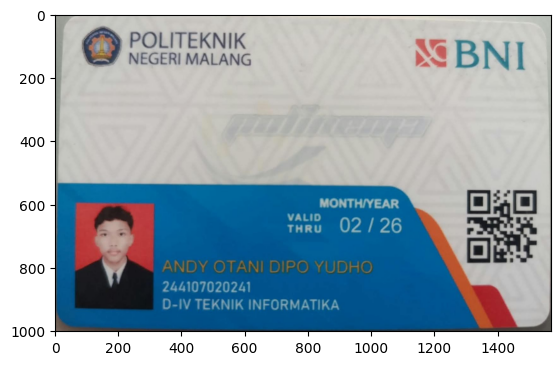

In [10]:
# 2. Menampilkan Gambar
# Untuk menampilkan Gambar, bisa menampilkan langsung (Image Display)salah satunya menggunakan library openCV dengan fungsi cv2.imshow() atau cv2_imshow()🡪di Google Colab atau menampilkan dalam Plot (Image Plotting) menggunakan library Matplotlib (plt.imshow).
img = cv.imread('ktm.jpg')
cv2_imshow(img) #format warna BGR

img = cv.imread('ktm.jpg')
img2 = cv.cvtColor(img, cv.COLOR_BGR2RGB) #koknversi channel BGR -> RGB
plt.imshow(img)
plt.show()

img = cv.imread('ktm.jpg')
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB)) #konversi channel BGR -> RGB
plt.show()


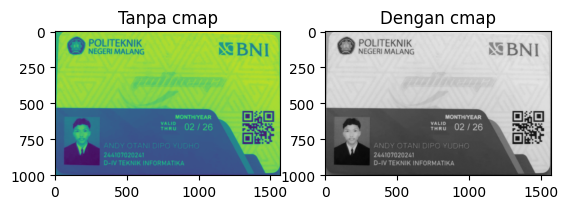

In [13]:
#3. Menampilkan citra Grayscale:
img_gray = cv.imread('ktm.jpg', cv.IMREAD_GRAYSCALE)

#Tanpa cmap
plt.subplot(1,2,1)
plt.imshow(img_gray)
plt.title('Tanpa cmap')

# Dengan cmap
plt.subplot(1,2,2)
plt.imshow(img_gray, cmap='gray')
#plt.imshow(img_gray, cmap='magma')
plt.title('Dengan cmap')

plt.show()

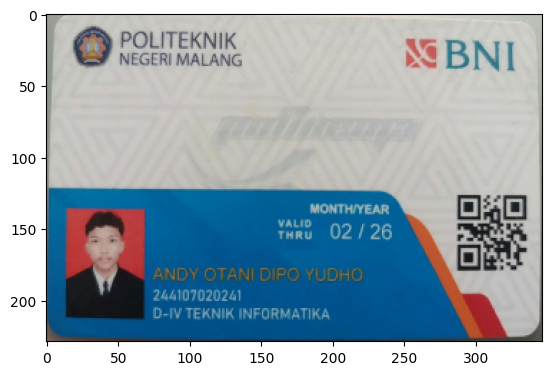

In [17]:
#4. Melakukan resizing
imgRGB = cv.cvtColor(img,cv.COLOR_BGR2RGB) #konversi BGR ke RGB
img_output = cv.resize(imgRGB, (347,229))
plt.imshow(img_output)
plt.show()


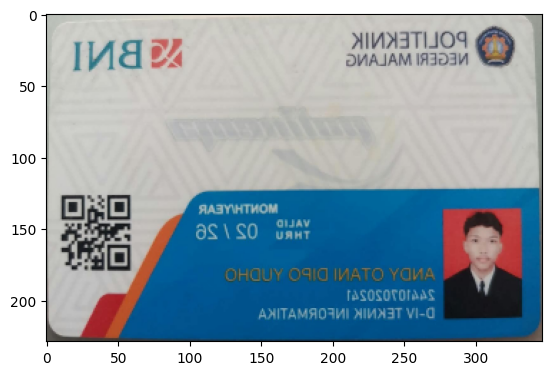

In [18]:
#5. Melakukan Flipping
imgFlip=cv.flip(img_output,1)
plt.imshow(imgFlip)

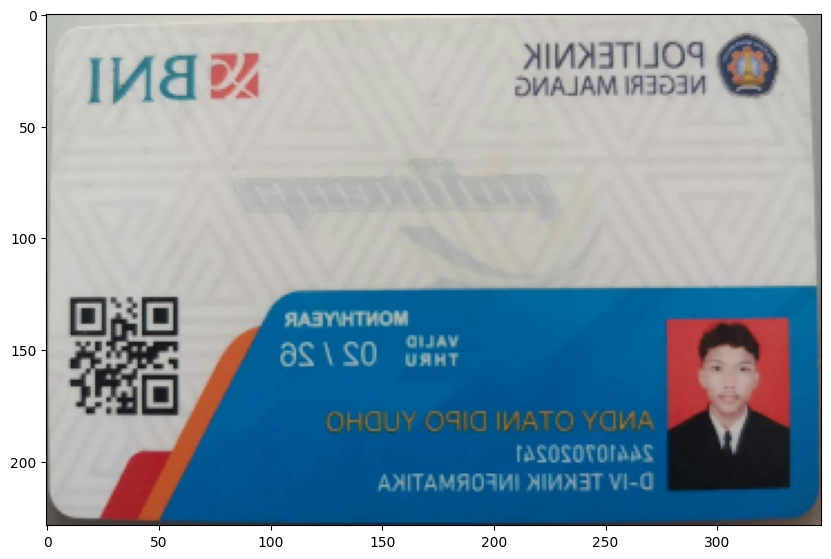

In [20]:
imgFlip=cv.flip(img_output,1)

#tampilkan ukuran canvas yang lebih besar
fig = plt.figure(figsize=(10,10))
ax=fig.add_subplot(1,1,1)
ax.imshow(imgFlip)

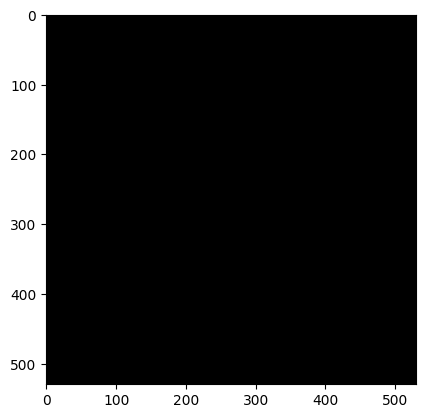

In [21]:
#6. Membuat bentuk Geometri 2D dari OpenCV. Diawali dengan pembuatan black image dengan tipe data int16.
black_img = np.zeros((530,530,3), dtype=np.int16)
plt.imshow(black_img)


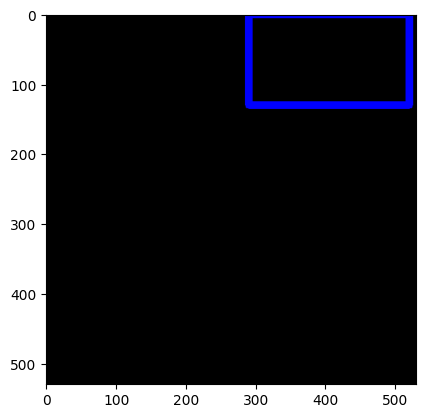

In [23]:
#perhatikan koordinat titik2 pt1 dan pt2
cv.rectangle(black_img,pt1=(290,0),pt2=(520,130),color=(0,0,255),thickness=10)
plt.imshow(black_img)

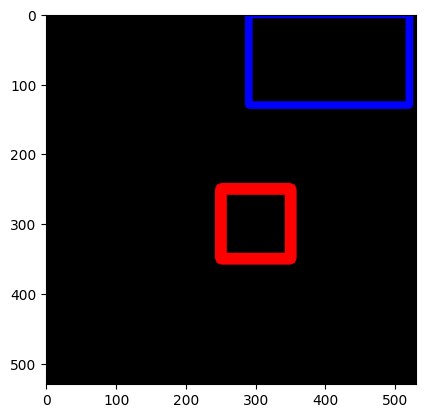

In [24]:
cv.rectangle(black_img,pt1=(250,250),pt2=(350,350),color=(255,0,0),thickness=15)
plt.imshow(black_img)

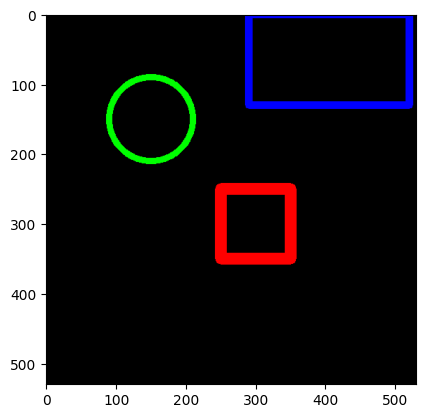

In [25]:
cv.circle(black_img,center=(150,150),radius=60,color=(0,255,0),thickness=8)
plt.imshow(black_img)

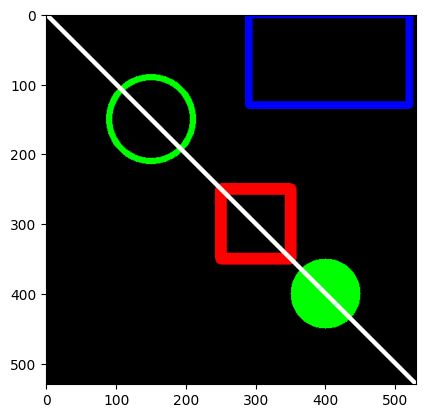

In [26]:
cv.circle(black_img,center=(400,400),radius=50,color=(0,255,0),thickness=-1)
cv.line(black_img,pt1=(0,0),pt2=(530,530),color=(255,255,255),thickness=5)
plt.imshow(black_img)

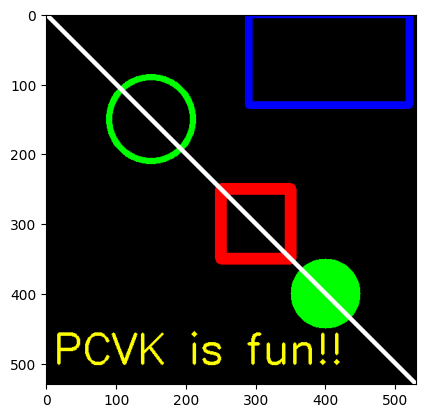

In [28]:
font = cv.FONT_HERSHEY_SIMPLEX
cv.putText(black_img, text='PCVK is fun!!', org=(10,500), fontFace=font, fontScale=2, color=(255,255,0), thickness=3, lineType=cv.LINE_AA)
plt.imshow(black_img)

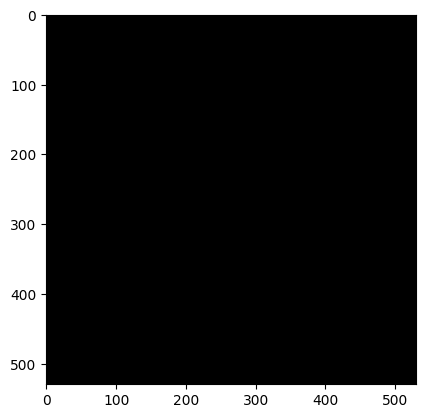

In [29]:
black_img2=np.zeros(shape=(530,530,3), dtype=np.int32)
plt.imshow(black_img2)

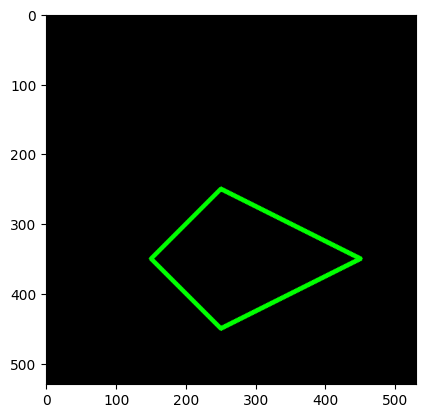

In [32]:
vertices = np.array([[150,350],[250,250],[450,350],[250,450]], dtype=np.int32)
vertices

# Output:
# array([[150, 350],
#        [250, 250],
#        [450, 350],
#        [250, 450]], dtype=int32)

# Array tersebut kemudian di reshape sebagai berikut
pts = vertices.reshape((-1, 2))  # nilai 2 untuk menunjukkan bahwa tiap titik dibuat 2 channel (x, y)
pts

# Output yang benar seharusnya:
# array([[150, 350],
#        [250, 250],
#        [450, 350],
#        [250, 450]], dtype=int32)

# Penambahan polyline pada black image kedua yang telah dibuat
cv.polylines(black_img2, [pts], isClosed=True, color=(0, 255, 0), thickness=5)
plt.imshow(black_img2)

In [ ]:
#7. Setelah semua kode selesai simpan “Week02.ipynb” pada GiHub Anda dengan memilih File kemudian “Save a copy in GitHub”.


PERTANYAAN PRAKTIKUM


1. Tampilkan satu citra bebas menggunakan cv2_imshow() dan plt.imshow()
tanpa konversi warna apa pun. Mengapa hasilnya berbeda? Buktikan dengan
mencetak nilai satu piksel yang sama dari kedua cara pembacaan tersebut.
2. Buat kanvas hitam berukuran sama dengan tipe data int16 dan int32.
Bandingkan dtype, min(), max(), dan nbytes keduanya. Apakah tampilannya
berbeda? Apakah ukuran memorinya berbeda? Jelaskan alasannya.
3. Apa kegunaan baris from google.colab.patches import cv2_imshow, dan
mengapa cv2.imshow() bawaan OpenCV tidak dapat dipakai di Google Colab?
4. Citra yang dibaca dengan skimage.io.imread() ditampilkan berdampingan
dengan hasil cv2.cvtColor(img, cv2.COLOR_BGR2RGB) atas citra yang
sama. Manakah yang menampilkan warna sebenarnya, dan manakah yang
kanalnya tertukar? Buktikan dengan nilai piksel, bukan dengan pengamatan
visual saja.
5. Setelah citra ditampilkan dengan figsize yang jauh lebih besar, apakah nilai
img.shape ikut berubah? Jelaskan perbedaan antara mengubah ukuran citra
dan mengubah ukuran tampilan.



TUGAS PRAKTIKUM - Penerapan

Berdasarkan praktikum bagian 1 dan 2 kerjakan beberapa tugas berikut :

Tampilkan citra hanya pada kombinasi

1. kanal Merah-Biru dan kanal Hijau-
Biru saja, dengan kanal yang tidak dipakai dinolkan. Susun keduanya berdampingan dalam satu figure yang diberi judul.
2. Tampilkan citra dalam tiga bentuk pencerminan: vertikal, horizontal, dan
keduanya, dalam satu figure berisi tiga subplot yang masing-masing diberi
label.
3. Gambarkan sebuah rectangle dan sebuah circle pada bagian wajah /
badan dari foto aktivitas Anda sendiri (bukan pasfoto), lalu tambahkan
teks berisi nama Anda dengan pilihan font, ukuran, dan warna yang Anda
tentukan sendiri.

TUGAS PRAKTIKUM - Analisa


1.   Rumuskan satu pertanyaan tentang citra digital yang dapat Anda jawab
menggunakan kode dari modul ini. Contoh pertanyaan: berapa persen
piksel pada foto KTM Anda yang lebih gelap dari nilai 100? apakah
mengecilkan lalu membesarkan citra mengubah rata-rata intensitasnya?
Tuliskan pertanyaan Anda, rancangan program, data hasilnya, dan
kesimpulan Anda.




TUGAS PRAKTIKUM - Aplikasi

Pada bagian ini, Anda hanya diperbolehkan memakai fungsi yang telah dipelajari
pada modul ini: pembacaan berkas, pengirisan, cv2.resize, cv2.flip, cv2.cvtColor,
fungsi penggambaran OpenCV, serta pembuatan kanvas dengan NumPy. Selain
itu, program harus bersifat adaptif, dimana setiap ukuran, posisi, atau ketebalan
harus dihitung dari ukuran citra masukan, bukan ditulis sebagai angka tetap pada
kode program.

Studi Kasus 1: Panitia sebuah kegiatan perlu membubuhkan label identitas pada
ratusan foto dokumentasi. Foto berasal dari beberapa kamera dan ponsel,
sehingga ukurannya bermacam-macam. Label harus terlihat seimbang pada
semua foto tanpa disetel satu per satu. Fungsi yang sama dikenakan pada dua
citra berbeda ukuran. Tinggi bar dan ukuran huruf ikut menyesuaikan, sehingga
proporsinya tetap sama.

Studi Kasus 2: Marketplace seperti Tokopedia dan Shopee menampilkan foto
produk dalam bingkai persegi 1:1. Foto penjual yang berukuran potrait atau
lanskap akan terpotong atau terlihat tidak proporsional bila diunggah begitu saja.
Bangun program yang mengubah foto berukuran apa pun menjadi thumbnail
persegi tanpa mengubah rasio aslinya, dengan sisa ruang diisi kanvas berwarna.
Dalam hal ini, rasio asli tetap terjaga, citra terpasang tepat di tengah kanvas,
tambahkan logo nama toko berukuran proporsional pada gambar.

